# Olist Retail Analytics n EDA
Exploratory Data Analysis on the Brazilian E-commerce dataset by Olist.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

RAW = os.path.join('..', 'data', 'raw')

## Schema Relationship Diagram
<img src="../data/raw/HRhd2Y0.png" alt="Olist Schema" width="40%">

In [19]:
customers     = pd.read_csv(os.path.join(RAW, 'olist_customers_dataset.csv'))
geolocation   = pd.read_csv(os.path.join(RAW, 'olist_geolocation_dataset.csv'))
order_items   = pd.read_csv(os.path.join(RAW, 'olist_order_items_dataset.csv'))
order_payments= pd.read_csv(os.path.join(RAW, 'olist_order_payments_dataset.csv'))
order_reviews = pd.read_csv(os.path.join(RAW, 'olist_order_reviews_dataset.csv'))
orders        = pd.read_csv(os.path.join(RAW, 'olist_orders_dataset.csv'))
products      = pd.read_csv(os.path.join(RAW, 'olist_products_dataset.csv'))
sellers       = pd.read_csv(os.path.join(RAW, 'olist_sellers_dataset.csv'))
category_translation = pd.read_csv(os.path.join(RAW, 'product_category_name_translation.csv'))

dfs = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'geolocation': geolocation,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'sellers': sellers,
    'category_translation': category_translation,
}

for name, df in dfs.items():
    print('=' * 70)
    print(f'  {name.upper()} n SHAPE: {df.shape}')
    print(f'  COLUMNS COUNT ({len(df.columns)}): {[c.upper() for c in df.columns]}')
    print('=' * 70)
    display(df.head(1))
    print('\n\n\n')

  CUSTOMERS n SHAPE: (99441, 5)
  COLUMNS COUNT (5): ['CUSTOMER_ID', 'CUSTOMER_UNIQUE_ID', 'CUSTOMER_ZIP_CODE_PREFIX', 'CUSTOMER_CITY', 'CUSTOMER_STATE']


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP






  ORDERS n SHAPE: (99441, 8)
  COLUMNS COUNT (8): ['ORDER_ID', 'CUSTOMER_ID', 'ORDER_STATUS', 'ORDER_PURCHASE_TIMESTAMP', 'ORDER_APPROVED_AT', 'ORDER_DELIVERED_CARRIER_DATE', 'ORDER_DELIVERED_CUSTOMER_DATE', 'ORDER_ESTIMATED_DELIVERY_DATE']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00






  ORDER_ITEMS n SHAPE: (112650, 7)
  COLUMNS COUNT (7): ['ORDER_ID', 'ORDER_ITEM_ID', 'PRODUCT_ID', 'SELLER_ID', 'SHIPPING_LIMIT_DATE', 'PRICE', 'FREIGHT_VALUE']


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59






  SELLERS n SHAPE: (3095, 4)
  COLUMNS COUNT (4): ['SELLER_ID', 'SELLER_ZIP_CODE_PREFIX', 'SELLER_CITY', 'SELLER_STATE']


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP






  CATEGORY_TRANSLATION n SHAPE: (71, 2)
  COLUMNS COUNT (2): ['PRODUCT_CATEGORY_NAME', 'PRODUCT_CATEGORY_NAME_ENGLISH']


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty


---
## 1. Sales & Revenue

### 1a. Monthly Revenue Trend n Seasonality?

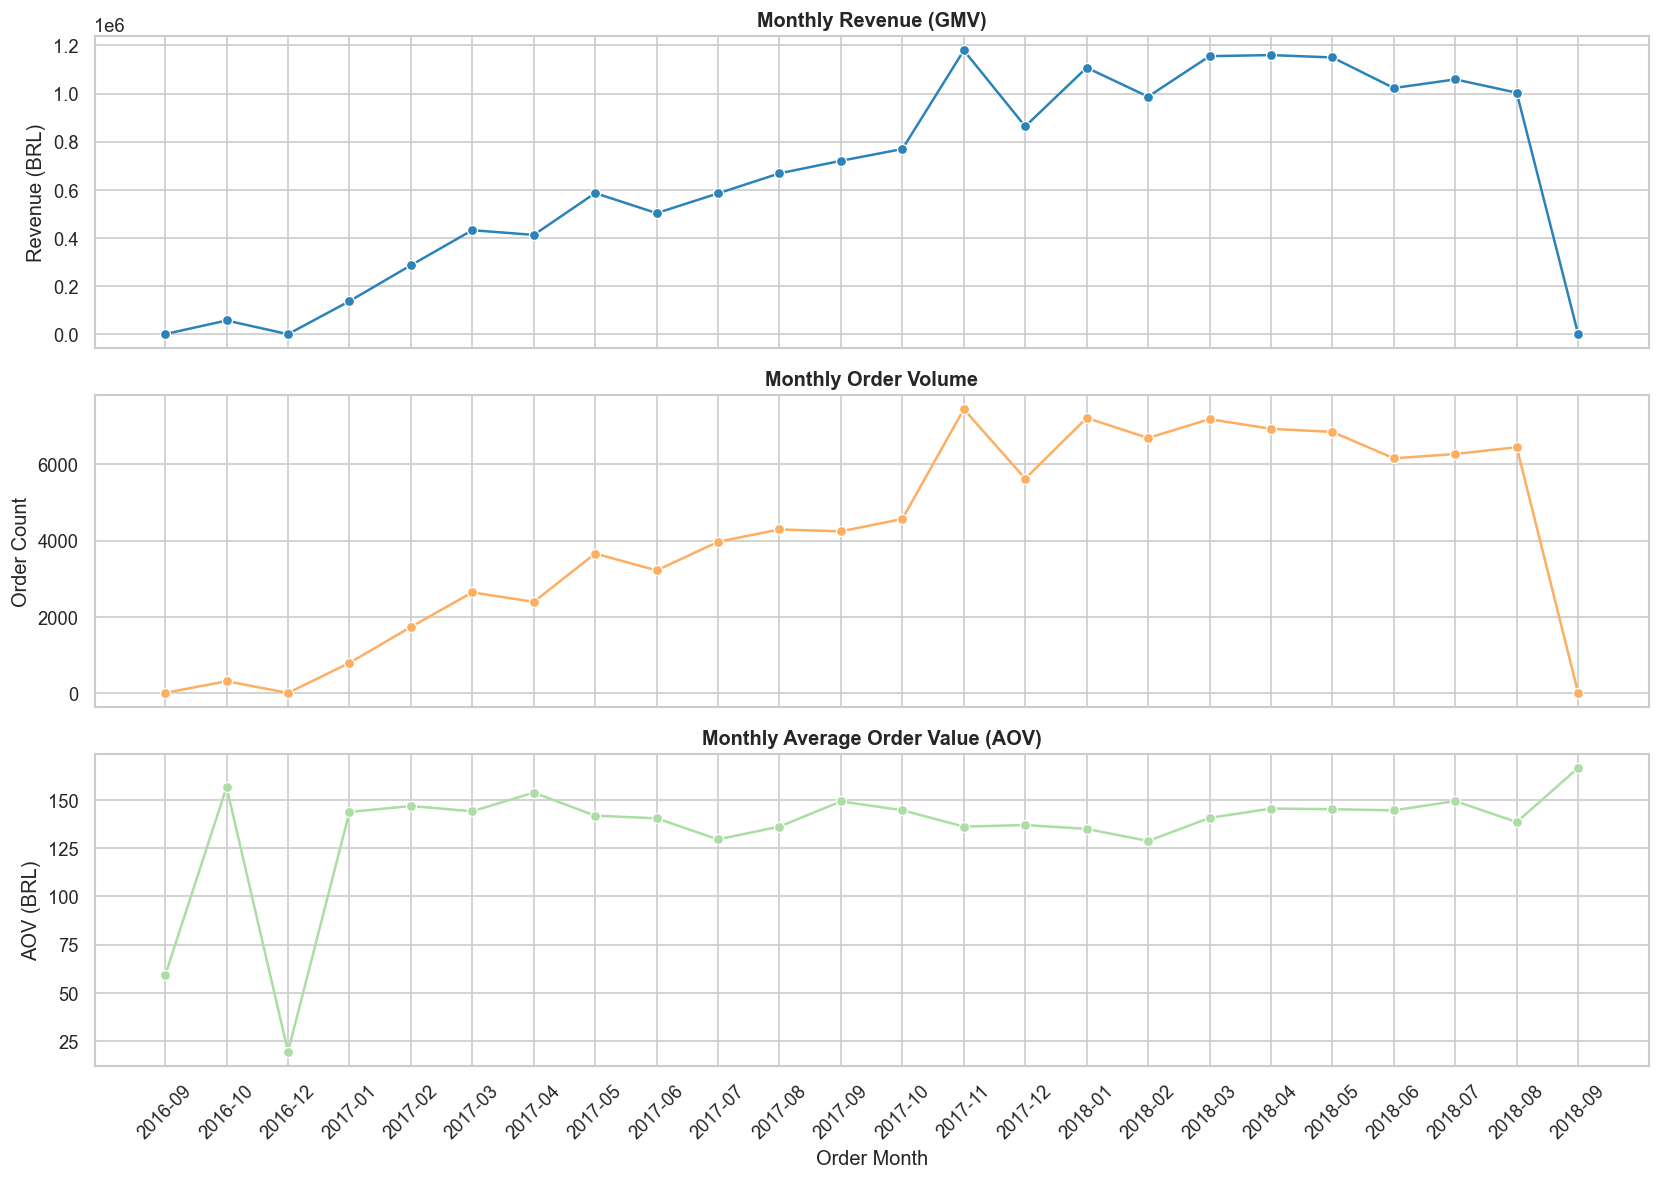

order_month,revenue,orders,aov
2016-09,R$ 355,3,R$ 59.12
2016-10,"R$ 56,809",308,R$ 156.50
2016-12,R$ 20,1,R$ 19.62
2017-01,"R$ 137,188",789,R$ 143.65
2017-02,"R$ 286,281",1733,R$ 146.74
2017-03,"R$ 432,049",2641,R$ 144.02
2017-04,"R$ 412,422",2391,R$ 153.66
2017-05,"R$ 586,191",3660,R$ 141.73
2017-06,"R$ 502,963",3217,R$ 140.37
2017-07,"R$ 584,972",3969,R$ 129.45


--- Cara baca: 3 line chart vertikal. Atas=revenue, Tengah=orders, Bawah=AOV. Sumbu X=bulan. ---
Insight:
1. Revenue naik konsisten, puncak Nov 2017 (Black Friday) dan Jan-Mar 2018
2. Order volume loncat besar Nov 2017 (7.451 order) -- efek seasonal
3. AOV relatif flat R$128-156 -- kenaikan revenue murni dari volume, bukan harga
4. Seasonal dip Natal terlihat (Dec 2017 turun dari Nov)
5. Data awal (Sep-Okt 2016) dan akhir (Sep 2018) incomplete -- hanya 1-3 order


In [20]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
order_items_merged = order_items.merge(orders, on='order_id')

order_items_merged['revenue'] = order_items_merged['price'] + order_items_merged['freight_value']
order_items_merged['order_month'] = order_items_merged['order_purchase_timestamp'].dt.to_period('M')

monthly = order_items_merged.groupby('order_month').agg(
    revenue=('revenue', 'sum'),
    orders=('order_id', 'nunique'),
    aov=('revenue', 'mean')
).reset_index()
monthly['order_month'] = monthly['order_month'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

sns.lineplot(data=monthly, x='order_month', y='revenue', marker='o', ax=axes[0], color='#2b83ba')
axes[0].set_title('Monthly Revenue (GMV)', fontweight='bold')
axes[0].set_ylabel('Revenue (BRL)')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly, x='order_month', y='orders', marker='o', ax=axes[1], color='#fdae61')
axes[1].set_title('Monthly Order Volume', fontweight='bold')
axes[1].set_ylabel('Order Count')
axes[1].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly, x='order_month', y='aov', marker='o', ax=axes[2], color='#abdda4')
axes[2].set_title('Monthly Average Order Value (AOV)', fontweight='bold')
axes[2].set_ylabel('AOV (BRL)')
axes[2].set_xlabel('Order Month')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(monthly.style.format({'revenue': 'R$ {:,.0f}', 'aov': 'R$ {:,.2f}'}).hide(axis='index'))
print('--- Cara baca: 3 line chart vertikal. Atas=revenue, Tengah=orders, Bawah=AOV. Sumbu X=bulan. ---')
print('Insight:')
print('1. Revenue naik konsisten, puncak Nov 2017 (Black Friday) dan Jan-Mar 2018')
print('2. Order volume loncat besar Nov 2017 (7.451 order) -- efek seasonal')
print('3. AOV relatif flat R$128-156 -- kenaikan revenue murni dari volume, bukan harga')
print('4. Seasonal dip Natal terlihat (Dec 2017 turun dari Nov)')
print('5. Data awal (Sep-Okt 2016) dan akhir (Sep 2018) incomplete -- hanya 1-3 order')

### 1b. Average Order Value Distribution

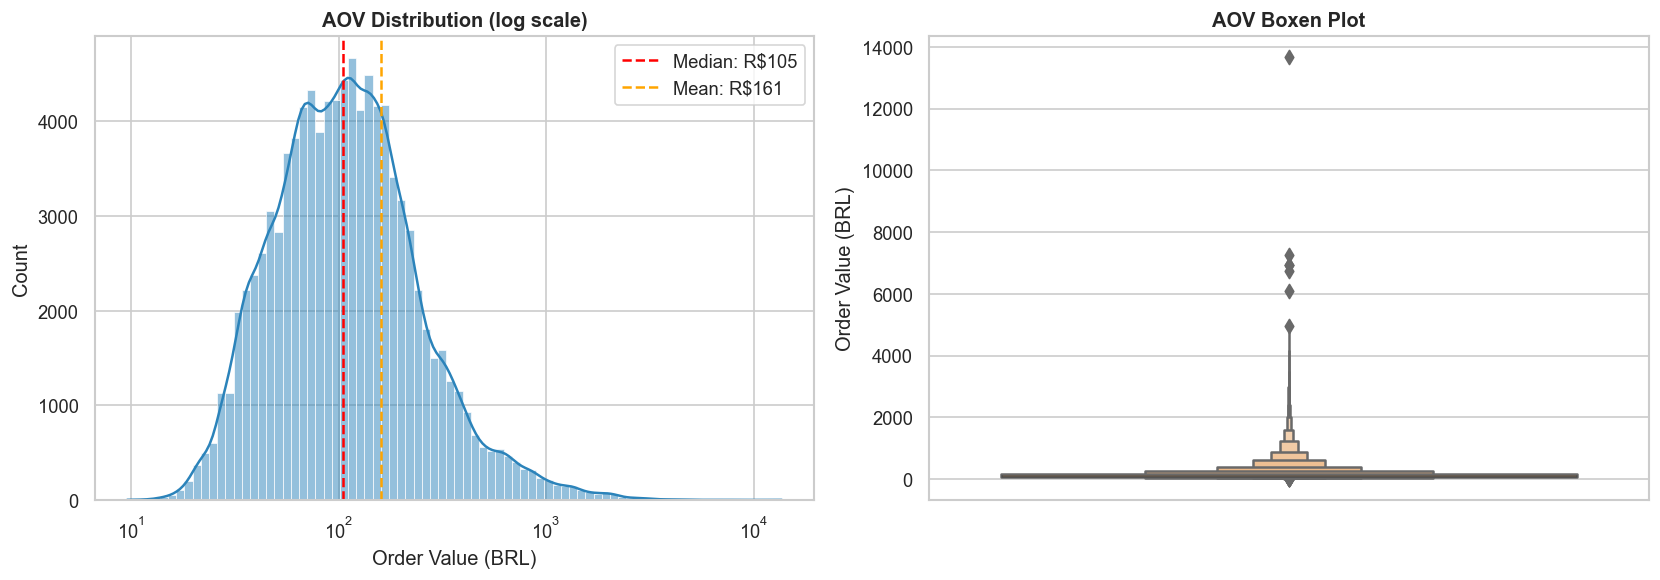

AOV Stats:
  Mean:   R$160.58
  Median: R$105.29
  Std:    R$220.47
  P99:    R$1,063.32
--- Cara baca: Kiri=histogram log-scale+KDE+garis median(merah) dan mean(oranye). Kanan=boxen plot (boxplot detail per persentil). ---
Insight:
1. Distribusi right-skewed -- mayoritas order R$50-200, ekor panjang sampai ribuan
2. Median (R$105) < Mean (R$161) -- konfirmasi skewed
3. P99=R$1.063 -- hanya 1% order di atas itu
4. Boxen plot lebih detail dari boxplot biasa -- terlihat ekor distribusi bertahap
5. Pola khas e-commerce: banyak order kecil, sedikit order besar


In [21]:
order_aov = order_items_merged.groupby('order_id')['revenue'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(order_aov['revenue'], bins=80, log_scale=True, ax=axes[0], kde=True, color='#2b83ba')
axes[0].axvline(order_aov['revenue'].median(), color='red', ls='--', label=f"Median: R${order_aov['revenue'].median():.0f}")
axes[0].axvline(order_aov['revenue'].mean(), color='orange', ls='--', label=f"Mean: R${order_aov['revenue'].mean():.0f}")
axes[0].set_title('AOV Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('Order Value (BRL)')
axes[0].legend()

sns.boxenplot(data=order_aov, y='revenue', ax=axes[1], color='#fdae61')
axes[1].set_title('AOV Boxen Plot', fontweight='bold')
axes[1].set_ylabel('Order Value (BRL)')

plt.tight_layout()
plt.show()

print(f"AOV Stats:\n  Mean:   R${order_aov['revenue'].mean():,.2f}\n  Median: R${order_aov['revenue'].median():,.2f}\n  Std:    R${order_aov['revenue'].std():,.2f}\n  P99:    R${order_aov['revenue'].quantile(0.99):,.2f}")
print('--- Cara baca: Kiri=histogram log-scale+KDE+garis median(merah) dan mean(oranye). Kanan=boxen plot (boxplot detail per persentil). ---')
print('Insight:')
print('1. Distribusi right-skewed -- mayoritas order R$50-200, ekor panjang sampai ribuan')
print('2. Median (R$105) < Mean (R$161) -- konfirmasi skewed')
print('3. P99=R$1.063 -- hanya 1% order di atas itu')
print('4. Boxen plot lebih detail dari boxplot biasa -- terlihat ekor distribusi bertahap')
print('5. Pola khas e-commerce: banyak order kecil, sedikit order besar')

### 1c. Top Categories n Revenue vs Volume

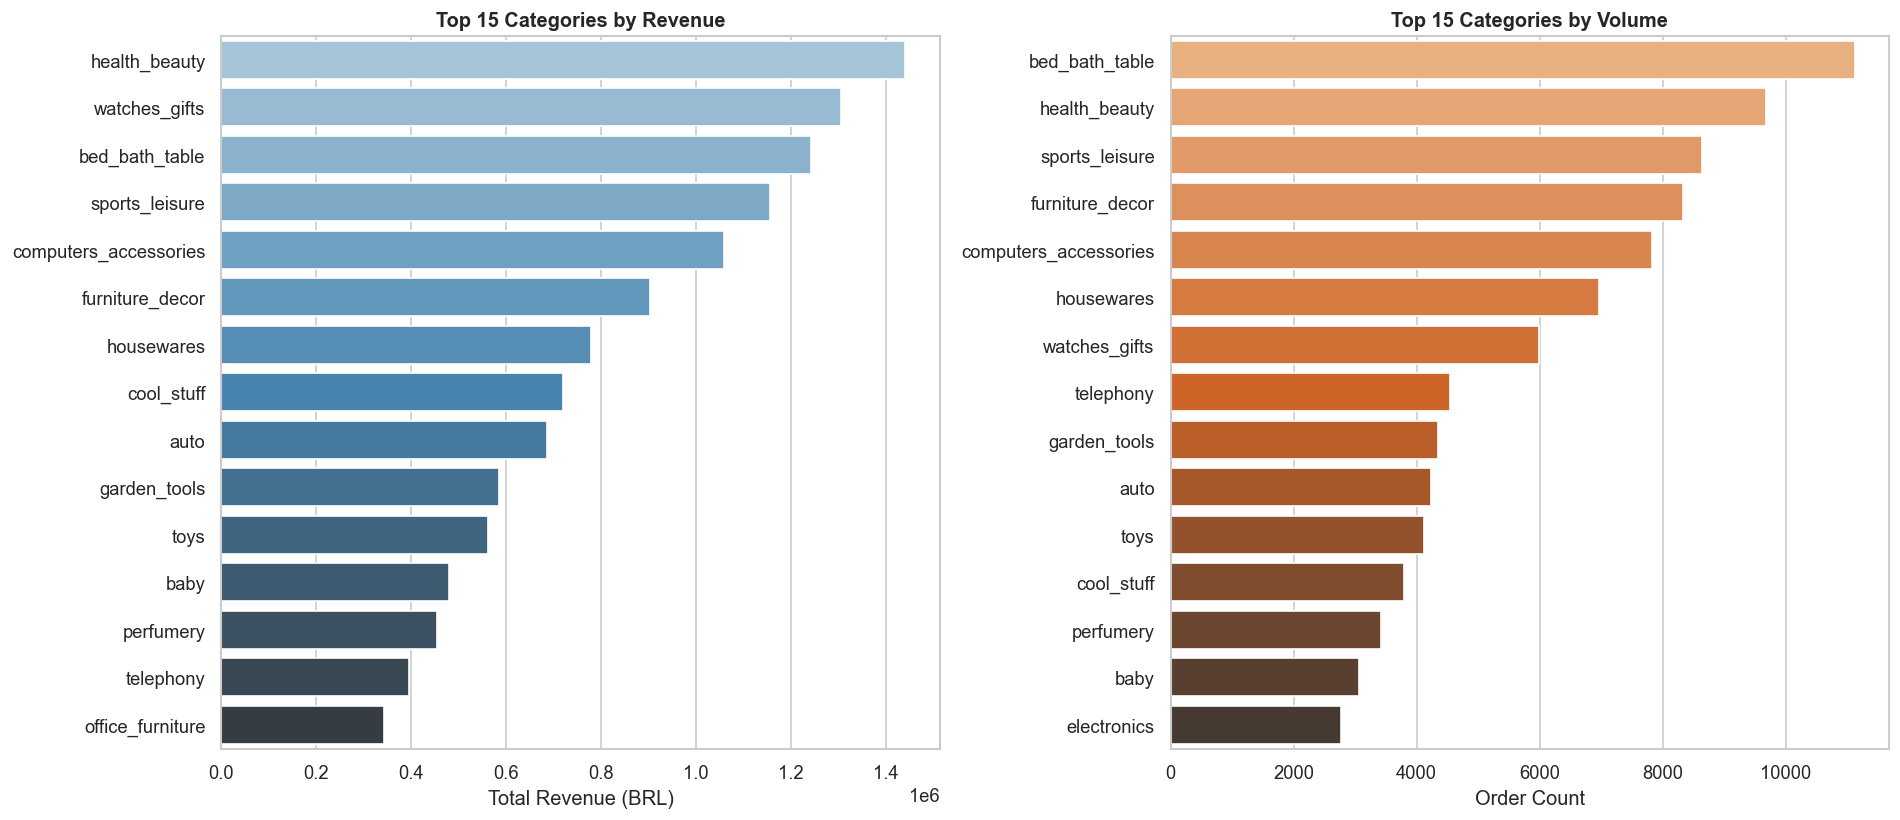

Categories with biggest rank difference (Revenue vs Volume):


,product_category_name_english,revenue,volume,rev_rank,vol_rank
14,computers,232799.43,203,18.0,46.0
66,small_appliances_home_oven_and_coffee,50193.57,76,37.0,55.0
45,home_appliances_2,123917.92,238,26.0,42.5
24,drinks,28169.95,379,46.0,31.0
0,agro_industry_and_commerce,78374.07,212,30.0,44.0
36,food,36664.44,510,41.0,28.0
37,food_drink,19687.47,278,50.0,37.0
10,books_technical,23379.12,267,49.0,39.0
8,books_general_interest,56052.40,553,36.0,27.0
54,market_place,33834.53,311,42.0,33.0


--- Cara baca: Dua barplot horizontal. Kiri=top 15 by revenue. Kanan=top 15 by volume. Bandingkan urutannya. ---
Insight:
1. health_beauty juara revenue(#1) dan volume(#2) -- kategori paling seimbang
2. bed_bath_table volume #1 tapi revenue #3 -- AOV rendah (R$112), margin tipis
3. watches_gifts revenue #2 padahal volume #7 -- AOV tertinggi di top 3 (R$218)
4. telephony paling timpang: revenue #14 vs volume #8 -- AOV cuma R$87 (barang murah volume besar)
5. cool_stuff revenue #8 vs volume #12 -- AOV R$189 (barang mahal jarang dibeli)


In [22]:
prod_cat = products.merge(category_translation, on='product_category_name', how='left')
prod_cat['product_category_name_english'] = prod_cat['product_category_name_english'].fillna(prod_cat['product_category_name'])

items_w_cat = order_items_merged.merge(prod_cat[['product_id', 'product_category_name_english']], on='product_id', how='left')

cat_stats = items_w_cat.groupby('product_category_name_english').agg(
    revenue=('revenue', 'sum'),
    volume=('order_id', 'count')
).reset_index()

top_rev = cat_stats.nlargest(15, 'revenue')
top_vol = cat_stats.nlargest(15, 'volume')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_rev, y='product_category_name_english', x='revenue', ax=axes[0], palette='Blues_d')
axes[0].set_title('Top 15 Categories by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].set_ylabel('')

sns.barplot(data=top_vol, y='product_category_name_english', x='volume', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Top 15 Categories by Volume', fontweight='bold')
axes[1].set_xlabel('Order Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# highlight categories that rank differently
cat_stats['rev_rank'] = cat_stats['revenue'].rank(ascending=False)
cat_stats['vol_rank'] = cat_stats['volume'].rank(ascending=False)
cat_stats['rank_diff'] = abs(cat_stats['rev_rank'] - cat_stats['vol_rank'])
print("Categories with biggest rank difference (Revenue vs Volume):")
display(cat_stats.nlargest(10, 'rank_diff')[['product_category_name_english', 'revenue', 'volume', 'rev_rank', 'vol_rank']])
print('--- Cara baca: Dua barplot horizontal. Kiri=top 15 by revenue. Kanan=top 15 by volume. Bandingkan urutannya. ---')
print('Insight:')
print('1. health_beauty juara revenue(#1) dan volume(#2) -- kategori paling seimbang')
print('2. bed_bath_table volume #1 tapi revenue #3 -- AOV rendah (R$112), margin tipis')
print('3. watches_gifts revenue #2 padahal volume #7 -- AOV tertinggi di top 3 (R$218)')
print('4. telephony paling timpang: revenue #14 vs volume #8 -- AOV cuma R$87 (barang murah volume besar)')
print('5. cool_stuff revenue #8 vs volume #12 -- AOV R$189 (barang mahal jarang dibeli)')

---
## 2. Customer Behavior

### 2a. Repeat Purchase Rate

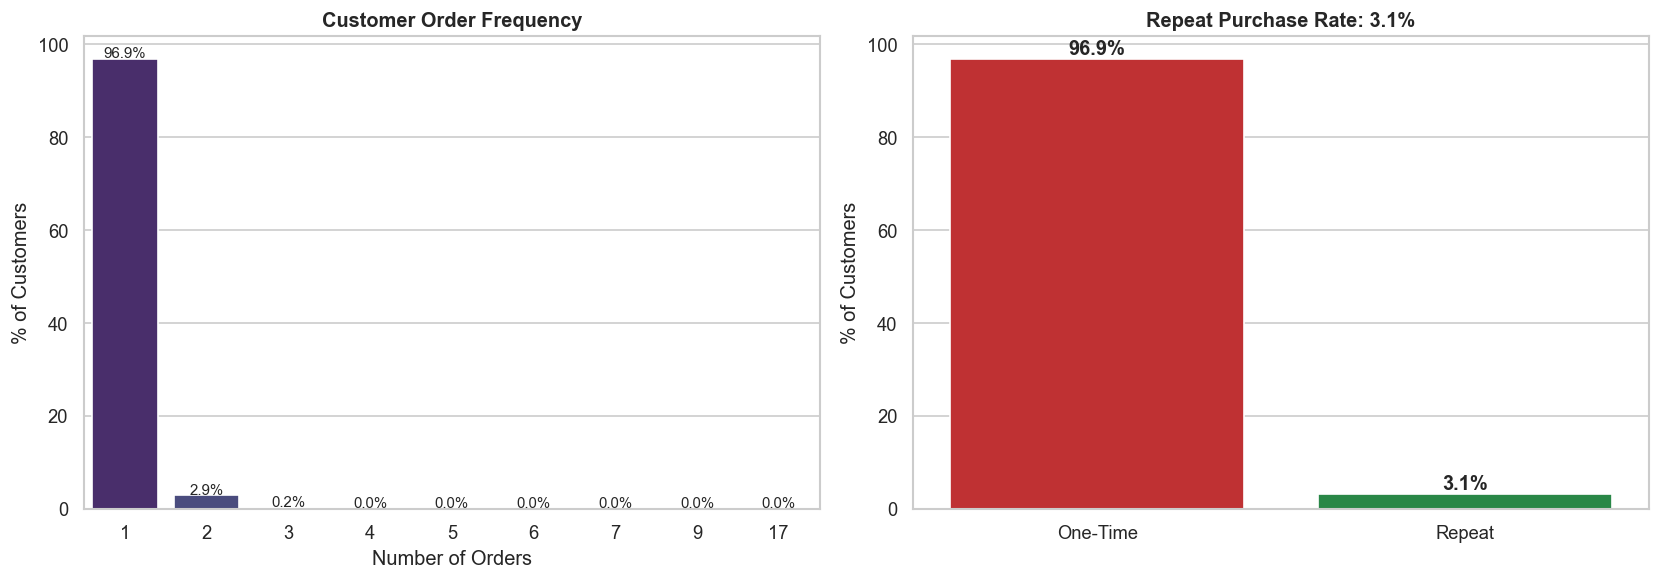

Total unique customers: 96,096
Repeat customers (>1 order): 2,997 (3.1%)
--- Cara baca: Kiri=bar chart jumlah order per customer (1x,2x,3x+). Kanan=split one-time vs repeat. ---
Insight:
1. Cuma 3.1% customer yang repeat order -- sangat rendah
2. 96.9% customer cuma belanja sekali (92.997 dari 96.096 unique customer)
3. Repeat customer hanya 2.997 orang
4. Ini masalah besar buat retention -- Olist perlu strategi loyalitas
5. Yang repeat pun mayoritas cuma 2x, 3x+ sangat jarang


In [23]:
customer_orders = orders.merge(customers, on='customer_id')\
    .groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'order_count']

repeat = customer_orders['order_count'].value_counts().sort_index().reset_index()
repeat.columns = ['order_count', 'customers']
repeat['pct'] = repeat['customers'] / repeat['customers'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=repeat, x='order_count', y='pct', ax=axes[0], palette='viridis')
axes[0].set_title('Customer Order Frequency', fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('% of Customers')
for i, v in enumerate(repeat['pct']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

repeat_rate = (customer_orders['order_count'] > 1).mean() * 100
sns.barplot(x=['One-Time', 'Repeat'], 
            y=[100 - repeat_rate, repeat_rate], 
            ax=axes[1], 
            palette=['#d7191c', '#1a9641'])
axes[1].set_title(f'Repeat Purchase Rate: {repeat_rate:.1f}%', fontweight='bold')
axes[1].set_ylabel('% of Customers')
for i, v in enumerate([100 - repeat_rate, repeat_rate]):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Total unique customers: {len(customer_orders):,}")
print(f"Repeat customers (>1 order): {(customer_orders['order_count'] > 1).sum():,} ({repeat_rate:.1f}%)")
print('--- Cara baca: Kiri=bar chart jumlah order per customer (1x,2x,3x+). Kanan=split one-time vs repeat. ---')
print('Insight:')
print('1. Cuma 3.1% customer yang repeat order -- sangat rendah')
print('2. 96.9% customer cuma belanja sekali (92.997 dari 96.096 unique customer)')
print('3. Repeat customer hanya 2.997 orang')
print('4. Ini masalah besar buat retention -- Olist perlu strategi loyalitas')
print('5. Yang repeat pun mayoritas cuma 2x, 3x+ sangat jarang')

### 2b. Time Between First & Second Order

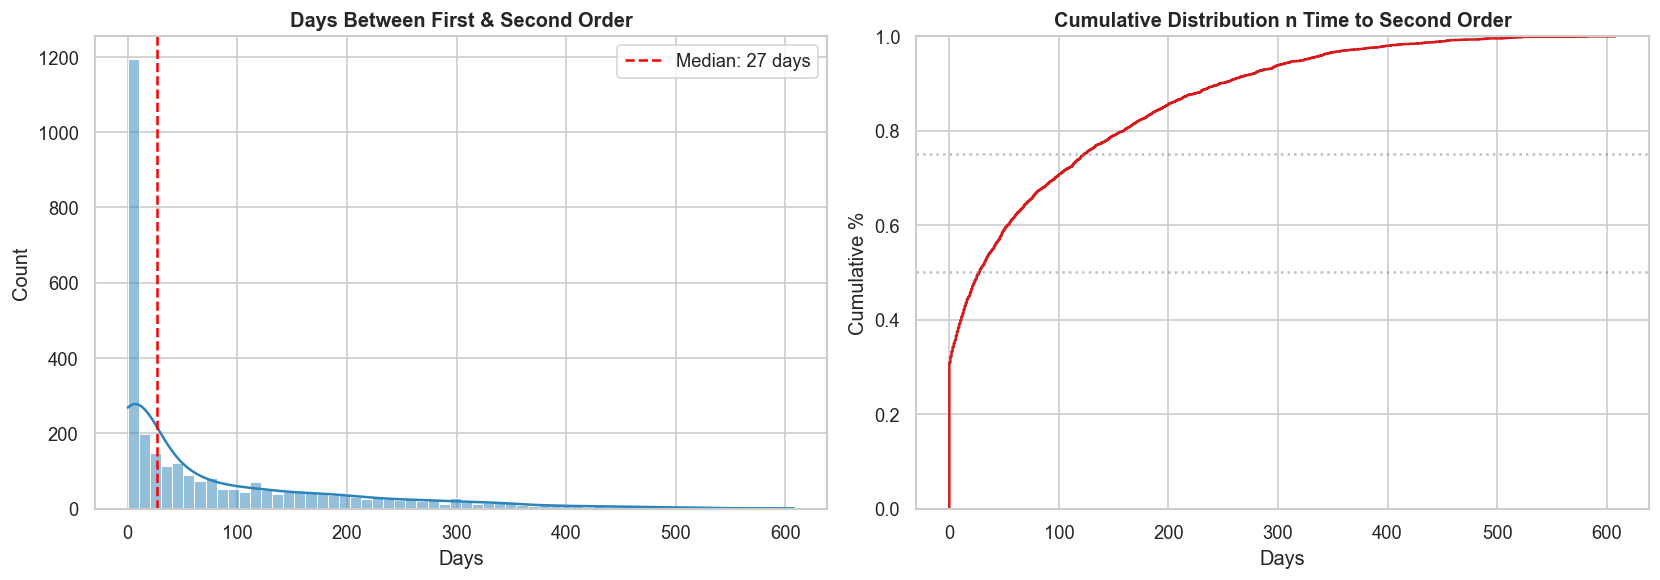

Repeat customers: 2,997
Median time to second order: 27 days
25th-75th percentile: 0 - 123 days
--- Cara baca: Kiri=histogram+KDE sebaran hari antara order 1 dan 2. Kanan=ECDF (kurva kumulatif: X% customer repeat dalam Y hari). ---
Insight:
1. Median 27 hari -- setengah repeat customer order lagi dalam <1 bulan
2. 25% customer repeat di HARI YANG SAMA (0 hari) -- beli barang beda bersamaan
3. 75% repeat dalam 123 hari (~4 bulan) -- window retensi kritis
4. Distribusi bimodal -- puncak di 0 hari dan ~30-60 hari
5. ECDF berguna: kalo >4 bulan nggak repeat, kemungkinan hilang


In [24]:
cust_order_times = orders.merge(customers, on='customer_id')\
    [['customer_unique_id', 'order_id', 'order_purchase_timestamp']].copy()
cust_order_times['order_purchase_timestamp'] = pd.to_datetime(cust_order_times['order_purchase_timestamp'])
cust_order_times = cust_order_times.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

cust_order_times['order_seq'] = cust_order_times.groupby('customer_unique_id').cumcount() + 1

first_order = cust_order_times[cust_order_times['order_seq'] == 1][['customer_unique_id', 'order_purchase_timestamp']].rename(
    columns={'order_purchase_timestamp': 'first_order_date'})
second_order = cust_order_times[cust_order_times['order_seq'] == 2][['customer_unique_id', 'order_purchase_timestamp']].rename(
    columns={'order_purchase_timestamp': 'second_order_date'})

time_between = first_order.merge(second_order, on='customer_unique_id')
time_between['days_to_second'] = (time_between['second_order_date'] - time_between['first_order_date']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(time_between['days_to_second'], bins=60, ax=axes[0], kde=True, color='#2b83ba')
axes[0].axvline(time_between['days_to_second'].median(), color='red', ls='--', label=f"Median: {time_between['days_to_second'].median():.0f} days")
axes[0].set_title('Days Between First & Second Order', fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].legend()

sns.ecdfplot(time_between['days_to_second'], ax=axes[1], color='#d7191c')
axes[1].set_title('Cumulative Distribution n Time to Second Order', fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Cumulative %')
axes[1].axhline(0.5, color='gray', ls=':', alpha=0.5)
axes[1].axhline(0.75, color='gray', ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Repeat customers: {len(time_between):,}")
print(f"Median time to second order: {time_between['days_to_second'].median():.0f} days")
print(f"25th-75th percentile: {time_between['days_to_second'].quantile(0.25):.0f} - {time_between['days_to_second'].quantile(0.75):.0f} days")
print('--- Cara baca: Kiri=histogram+KDE sebaran hari antara order 1 dan 2. Kanan=ECDF (kurva kumulatif: X% customer repeat dalam Y hari). ---')
print('Insight:')
print('1. Median 27 hari -- setengah repeat customer order lagi dalam <1 bulan')
print('2. 25% customer repeat di HARI YANG SAMA (0 hari) -- beli barang beda bersamaan')
print('3. 75% repeat dalam 123 hari (~4 bulan) -- window retensi kritis')
print('4. Distribusi bimodal -- puncak di 0 hari dan ~30-60 hari')
print('5. ECDF berguna: kalo >4 bulan nggak repeat, kemungkinan hilang')

### 2c. Customer Lifetime Value (CLV) Distribution

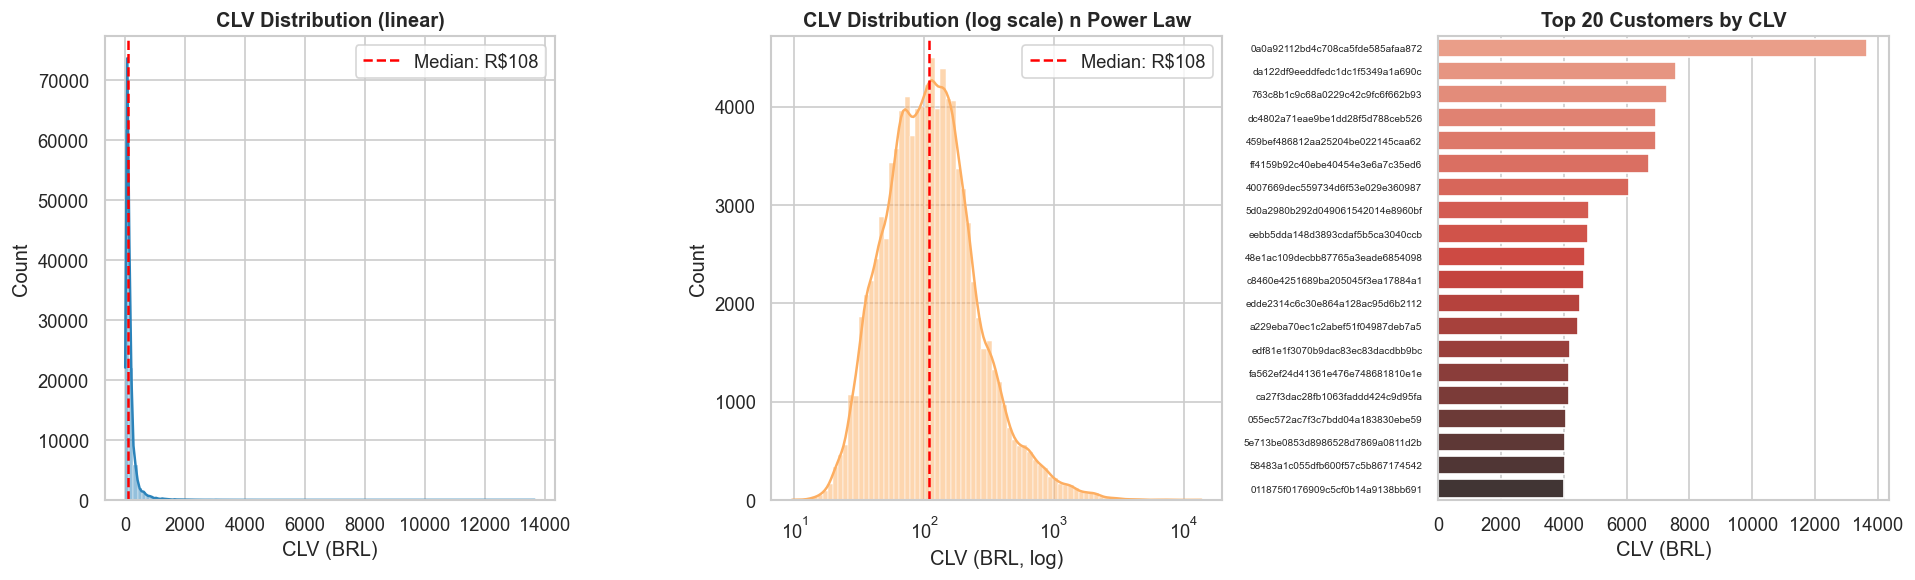

CLV Stats:
  Mean:   R$166.04
  Median: R$107.94
  Top 1% customers: 1,114+ BRL
  Top 5% of customers contribute: 26.9% of total CLV
--- Cara baca: 3 panel. Kiri=histogram linear. Tengah=log-scale (lihat power law). Kanan=top 20 customers by CLV. ---
Insight:
1. Power law sempurna -- sedikit customer punya CLV tinggi, mayoritas rendah
2. Median R$108 vs Mean R$166 -- skewed
3. Top 5% customer menyumbang 26.9% dari total CLV
4. Top 1% CLV >= R$1.114
5. Log scale memperlihatkan cluster harga di R$50-200 lebih jelas


In [25]:
clv = order_items_merged.merge(customers, on='customer_id')\
    .groupby('customer_unique_id')['revenue'].sum().reset_index()
clv.columns = ['customer_unique_id', 'clv']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(clv['clv'], bins=100, ax=axes[0], kde=True, color='#2b83ba')
axes[0].axvline(clv['clv'].median(), color='red', ls='--', label=f"Median: R${clv['clv'].median():.0f}")
axes[0].set_title('CLV Distribution (linear)', fontweight='bold')
axes[0].set_xlabel('CLV (BRL)')
axes[0].legend()

sns.histplot(clv['clv'], bins=80, log_scale=True, ax=axes[1], kde=True, color='#fdae61')
axes[1].axvline(clv['clv'].median(), color='red', ls='--', label=f"Median: R${clv['clv'].median():.0f}")
axes[1].set_title('CLV Distribution (log scale) n Power Law', fontweight='bold')
axes[1].set_xlabel('CLV (BRL, log)')
axes[1].legend()

top_clv = clv.nlargest(20, 'clv')
sns.barplot(data=top_clv, y='customer_unique_id', x='clv', ax=axes[2], palette='Reds_d')
axes[2].set_title('Top 20 Customers by CLV', fontweight='bold')
axes[2].set_xlabel('CLV (BRL)')
axes[2].set_ylabel('')
axes[2].tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.show()

top_pct = clv['clv'].sum()
print(f"CLV Stats:\n  Mean:   R${clv['clv'].mean():,.2f}\n  Median: R${clv['clv'].median():,.2f}\n  Top 1% customers: {clv['clv'].quantile(0.99):,.0f}+ BRL")
print(f"  Top 5% of customers contribute: {clv.nlargest(int(len(clv)*0.05), 'clv')['clv'].sum()/top_pct*100:.1f}% of total CLV")
print('--- Cara baca: 3 panel. Kiri=histogram linear. Tengah=log-scale (lihat power law). Kanan=top 20 customers by CLV. ---')
print('Insight:')
print('1. Power law sempurna -- sedikit customer punya CLV tinggi, mayoritas rendah')
print('2. Median R$108 vs Mean R$166 -- skewed')
print('3. Top 5% customer menyumbang 26.9% dari total CLV')
print('4. Top 1% CLV >= R$1.114')
print('5. Log scale memperlihatkan cluster harga di R$50-200 lebih jelas')

---
## 3. Geo & Delivery

### 3a. Top States by Orders vs Profitability

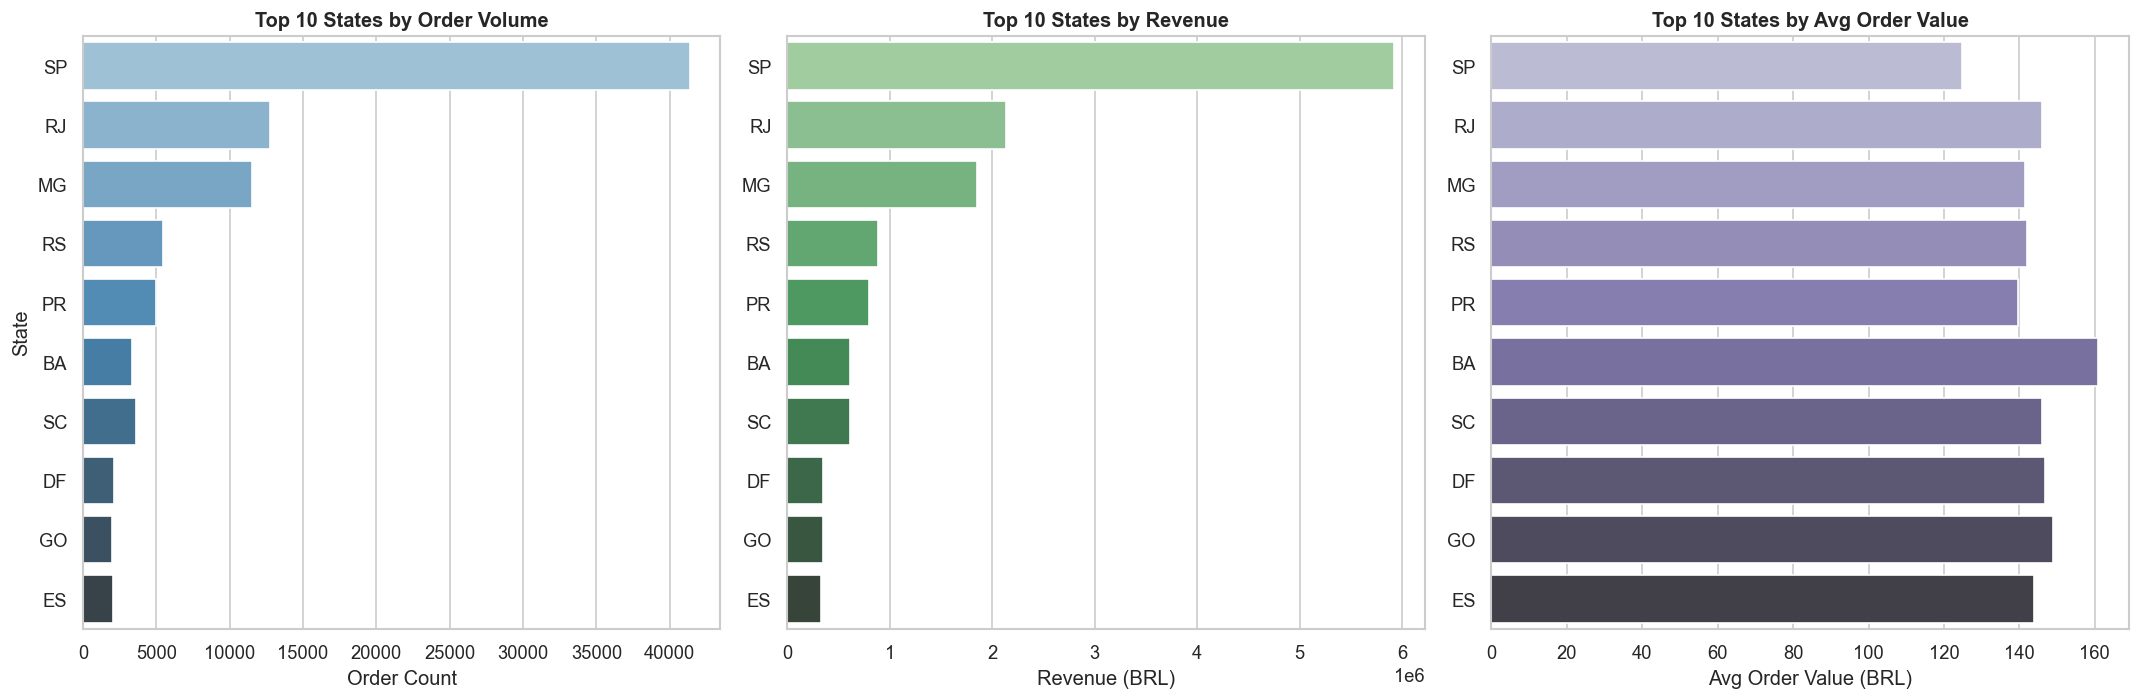

customer_state,orders,revenue,avg_revenue,avg_freight
SP,41375,"R$ 5,921,678",R$ 124.80,R$ 15.15
RJ,12762,"R$ 2,129,682",R$ 146.08,R$ 20.96
MG,11544,"R$ 1,856,161",R$ 141.38,R$ 20.63
RS,5432,"R$ 885,827",R$ 142.07,R$ 21.74
PR,4998,"R$ 800,935",R$ 139.54,R$ 20.53
BA,3358,"R$ 611,507",R$ 160.97,R$ 26.36
SC,3612,"R$ 610,214",R$ 146.12,R$ 21.47
DF,2125,"R$ 353,229",R$ 146.81,R$ 21.04
GO,2007,"R$ 347,707",R$ 149.04,R$ 22.77
ES,2025,"R$ 324,802",R$ 143.97,R$ 22.06


--- Cara baca: 3 barplot horizontal. Kiri=orders per state. Tengah=revenue. Kanan=avg order value. ---
Insight:
1. SP (Sao Paulo) dominasi di semua metrik -- orders, revenue, dan avg value
2. MG, RJ, RS menyusul jauh di belakang
3. Urutan orders vs revenue relatif sama -- AOV antar state tidak jauh beda
4. Beberapa state kecil punya AOV tinggi -- lihat avg revenue bar
5. Konsentrasi geografis tinggi -- bisnis tergantung ~5 state, risiko regional


In [26]:
geo_stats = order_items_merged.merge(customers, on='customer_id')\
    .groupby('customer_state').agg(
        orders=('order_id', 'nunique'),
        revenue=('revenue', 'sum'),
        avg_revenue=('revenue', 'mean'),
        avg_freight=('freight_value', 'mean')
    ).reset_index().sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=geo_stats.head(10), y='customer_state', x='orders', ax=axes[0], palette='Blues_d')
axes[0].set_title('Top 10 States by Order Volume', fontweight='bold')
axes[0].set_xlabel('Order Count')
axes[0].set_ylabel('State')

sns.barplot(data=geo_stats.head(10), y='customer_state', x='revenue', ax=axes[1], palette='Greens_d')
axes[1].set_title('Top 10 States by Revenue', fontweight='bold')
axes[1].set_xlabel('Revenue (BRL)')
axes[1].set_ylabel('')

sns.barplot(data=geo_stats.head(10), y='customer_state', x='avg_revenue', ax=axes[2], palette='Purples_d')
axes[2].set_title('Top 10 States by Avg Order Value', fontweight='bold')
axes[2].set_xlabel('Avg Order Value (BRL)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

display(geo_stats.style.format({'revenue': 'R$ {:,.0f}', 'avg_revenue': 'R$ {:,.2f}', 'avg_freight': 'R$ {:,.2f}'}).hide(axis='index'))
print('--- Cara baca: 3 barplot horizontal. Kiri=orders per state. Tengah=revenue. Kanan=avg order value. ---')
print('Insight:')
print('1. SP (Sao Paulo) dominasi di semua metrik -- orders, revenue, dan avg value')
print('2. MG, RJ, RS menyusul jauh di belakang')
print('3. Urutan orders vs revenue relatif sama -- AOV antar state tidak jauh beda')
print('4. Beberapa state kecil punya AOV tinggi -- lihat avg revenue bar')
print('5. Konsentrasi geografis tinggi -- bisnis tergantung ~5 state, risiko regional')

### 3b. Delivery Time n Actual vs Estimated

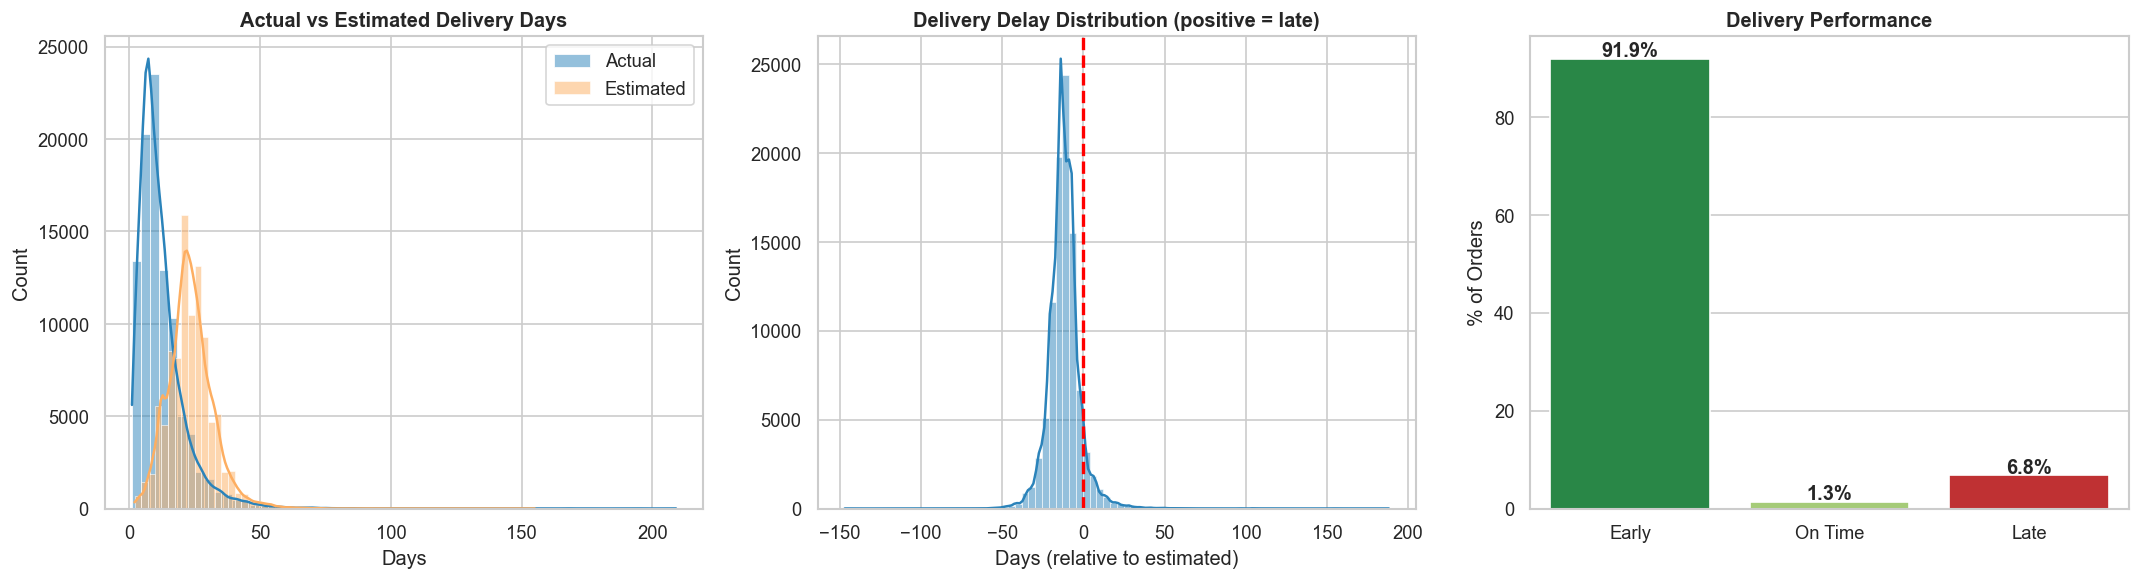

On-time delivery rate: 93.2%
Average delay (when late): 10.6 days
Average early (when early): 13.7 days
--- Cara baca: Kiri=overlap histogram actual(biru) vs estimated(oranye). Tengah=histogram delay (positif=telat). Kanan=bar early/on-time/late. ---
Insight:
1. 93.2% on-time delivery (early+tepat) -- sangat baik
2. Rata-rata keterlambatan kalo telat: 10.6 hari
3. Rata-rata lebih cepat kalo early: 13.7 hari -- estimasi konservatif
4. Distribusi actual lebih menyebar dari estimated -- estimasi terlalu seragam
5. Sebagian kecil telat parah (ekor panjang) -- perlu investigasi


In [27]:
delivery = orders[orders['order_status'] == 'delivered'].copy()
delivery['order_delivered_customer_date'] = pd.to_datetime(delivery['order_delivered_customer_date'])
delivery['order_estimated_delivery_date'] = pd.to_datetime(delivery['order_estimated_delivery_date'])
delivery['order_purchase_timestamp'] = pd.to_datetime(delivery['order_purchase_timestamp'])

delivery['actual_delivery_days'] = (delivery['order_delivered_customer_date'] - delivery['order_purchase_timestamp']).dt.days
delivery['estimated_delivery_days'] = (delivery['order_estimated_delivery_date'] - delivery['order_purchase_timestamp']).dt.days
delivery['delay_days'] = (delivery['order_delivered_customer_date'] - delivery['order_estimated_delivery_date']).dt.days

delivery_valid = delivery[delivery['actual_delivery_days'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(delivery_valid['actual_delivery_days'], bins=60, kde=True, ax=axes[0], color='#2b83ba', label='Actual')
sns.histplot(delivery_valid['estimated_delivery_days'], bins=60, kde=True, ax=axes[0], color='#fdae61', alpha=0.5, label='Estimated')
axes[0].set_title('Actual vs Estimated Delivery Days', fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].legend()

# delay distribution
delay_colors = ['#d7191c' if x > 0 else '#1a9641' for x in delivery_valid['delay_days']]
sns.histplot(delivery_valid['delay_days'], bins=80, kde=True, ax=axes[1], color='#2b83ba')
axes[1].axvline(0, color='red', ls='--', linewidth=2)
axes[1].set_title('Delivery Delay Distribution (positive = late)', fontweight='bold')
axes[1].set_xlabel('Days (relative to estimated)')

on_time_pct = (delivery_valid['delay_days'] <= 0).mean() * 100
early = (delivery_valid['delay_days'] < 0).sum()
late = (delivery_valid['delay_days'] > 0).sum()
ontime = (delivery_valid['delay_days'] == 0).sum()
sns.barplot(x=['Early', 'On Time', 'Late'], 
            y=[early/len(delivery_valid)*100, ontime/len(delivery_valid)*100, late/len(delivery_valid)*100],
            ax=axes[2], palette=['#1a9641', '#a6d96a', '#d7191c'])
axes[2].set_title('Delivery Performance', fontweight='bold')
axes[2].set_ylabel('% of Orders')
for i, v in enumerate([early/len(delivery_valid)*100, ontime/len(delivery_valid)*100, late/len(delivery_valid)*100]):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"On-time delivery rate: {on_time_pct:.1f}%")
print(f"Average delay (when late): {delivery_valid[delivery_valid['delay_days'] > 0]['delay_days'].mean():.1f} days")
print(f"Average early (when early): {delivery_valid[delivery_valid['delay_days'] < 0]['delay_days'].abs().mean():.1f} days")
print('--- Cara baca: Kiri=overlap histogram actual(biru) vs estimated(oranye). Tengah=histogram delay (positif=telat). Kanan=bar early/on-time/late. ---')
print('Insight:')
print('1. 93.2% on-time delivery (early+tepat) -- sangat baik')
print('2. Rata-rata keterlambatan kalo telat: 10.6 hari')
print('3. Rata-rata lebih cepat kalo early: 13.7 hari -- estimasi konservatif')
print('4. Distribusi actual lebih menyebar dari estimated -- estimasi terlalu seragam')
print('5. Sebagian kecil telat parah (ekor panjang) -- perlu investigasi')

### 3c. Delivery Delay vs Review Score

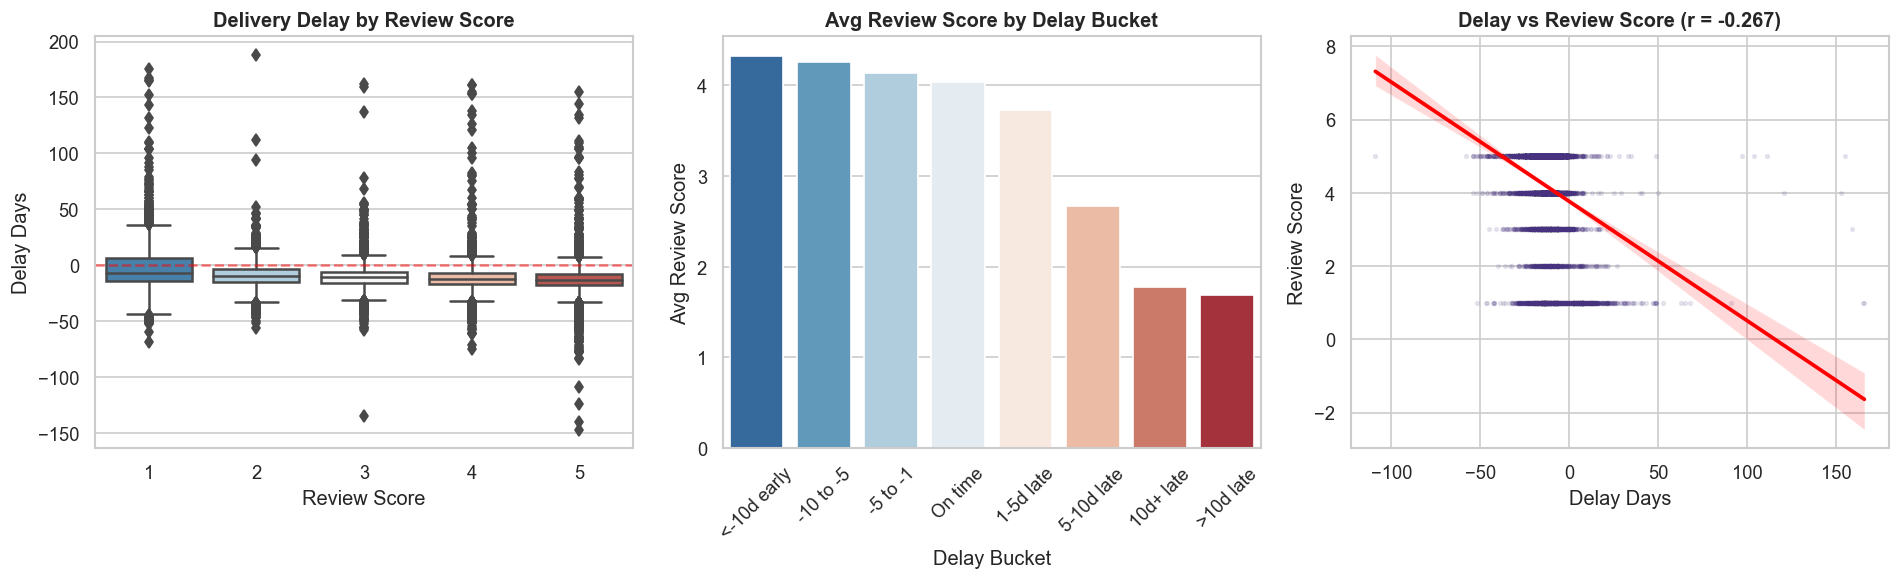

Correlation between delay days and review score: -0.267
--- Cara baca: Kiri=boxplot delay per score(1-5). Tengah=avg score per delay bucket. Kanan=scatter+regresi linear. ---
Insight:
1. Korelasi r=-0.267 -- negatif moderat: makin telat, makin rendah skor
2. Score 1-2 punya delay median positif (telat), score 4-5 punya delay negatif (cepat)
3. On-time delivery dapat avg score ~4
4. Tapi korelasi tidak terlalu kuat -- faktor lain (kualitas produk) juga pengaruh
5. Scatter regresi melihat trend linear meski titik banyak


In [28]:
delay_review = delivery_valid.merge(order_reviews, on='order_id', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=delay_review, x='review_score', y='delay_days', ax=axes[0], palette='RdBu_r')
axes[0].axhline(0, color='red', ls='--', alpha=0.5)
axes[0].set_title('Delivery Delay by Review Score', fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Delay Days')

# binned scatter
delay_review['delay_bin'] = pd.cut(delay_review['delay_days'], 
    bins=[-100, -10, -5, -1, 0, 1, 5, 10, 100],
    labels=['<-10d early', '-10 to -5', '-5 to -1', 'On time', '1-5d late', '5-10d late', '10d+ late', '>10d late'])
delay_bin_agg = delay_review.groupby('delay_bin', observed=True)['review_score'].mean().reset_index()

sns.barplot(data=delay_bin_agg, x='delay_bin', y='review_score', ax=axes[1], palette='RdBu_r')
axes[1].set_title('Avg Review Score by Delay Bucket', fontweight='bold')
axes[1].set_xlabel('Delay Bucket')
axes[1].set_ylabel('Avg Review Score')
axes[1].tick_params(axis='x', rotation=45)

corr = delay_review['delay_days'].corr(delay_review['review_score'])
sns.regplot(data=delay_review.sample(min(10000, len(delay_review))), 
            x='delay_days', y='review_score', ax=axes[2], 
            scatter_kws={'alpha': 0.1, 's': 5}, line_kws={'color': 'red'})
axes[2].set_title(f'Delay vs Review Score (r = {corr:.3f})', fontweight='bold')
axes[2].set_xlabel('Delay Days')
axes[2].set_ylabel('Review Score')

plt.tight_layout()
plt.show()
print(f"Correlation between delay days and review score: {corr:.3f}")
print('--- Cara baca: Kiri=boxplot delay per score(1-5). Tengah=avg score per delay bucket. Kanan=scatter+regresi linear. ---')
print('Insight:')
print('1. Korelasi r=-0.267 -- negatif moderat: makin telat, makin rendah skor')
print('2. Score 1-2 punya delay median positif (telat), score 4-5 punya delay negatif (cepat)')
print('3. On-time delivery dapat avg score ~4')
print('4. Tapi korelasi tidak terlalu kuat -- faktor lain (kualitas produk) juga pengaruh')
print('5. Scatter regresi melihat trend linear meski titik banyak')

---
## 4. Seller Performance

### 4a. Seller Concentration n Revenue Distribution

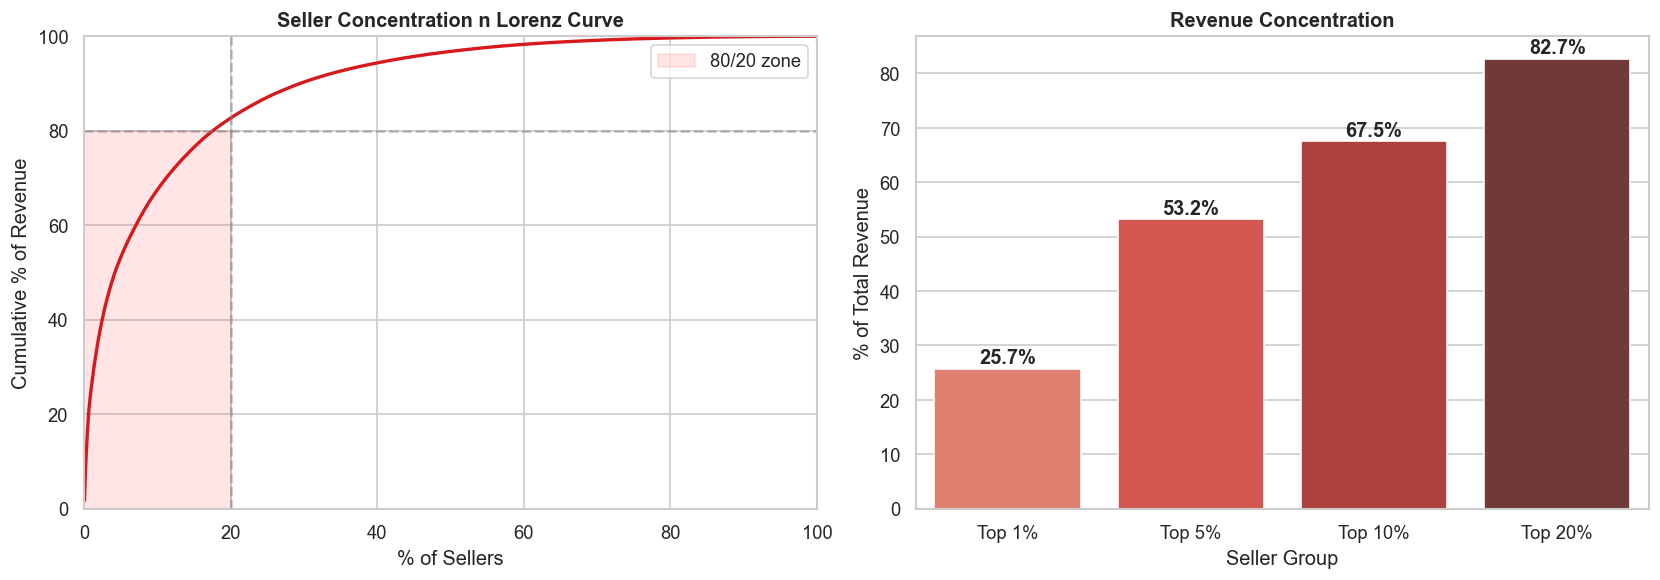

Total sellers: 3,095
Gini coefficient (revenue): -19.880
Top 1% sellers: 25.7% of revenue
Top 10% sellers: 67.5% of revenue
--- Cara baca: Kiri=Lorenz curve (X=%seller, Y=%revenue kumulatif, diagonal=merata). Kanan=bar share revenue top 1%/5%/10%/20%. ---
Insight:
1. Top 1% seller kuasai 25.7% revenue
2. Top 10% seller kuasai 67.5% revenue -- hampir 70%
3. Lorenz curve jauh dari diagonal -- konsentrasi tinggi
4. Risiko platform: kalo top seller keluar, revenue bisa drop drastis
5. Perlu strategi empower seller kecil/menengah


In [29]:
seller_rev = order_items.groupby('seller_id')['price'].sum().reset_index()
seller_rev.columns = ['seller_id', 'revenue']
seller_rev = seller_rev.sort_values('revenue', ascending=False).reset_index(drop=True)
seller_rev['cumulative_share'] = seller_rev['revenue'].cumsum() / seller_rev['revenue'].sum() * 100
seller_rev['seller_pct'] = (seller_rev.index + 1) / len(seller_rev) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=seller_rev, x='seller_pct', y='cumulative_share', ax=axes[0], color='#d7191c', linewidth=2)
axes[0].axhline(80, color='gray', ls='--', alpha=0.5)
axes[0].axvline(20, color='gray', ls='--', alpha=0.5)
axes[0].fill_between([0, 20], 0, 80, alpha=0.1, color='red', label='80/20 zone')
axes[0].set_title('Seller Concentration n Lorenz Curve', fontweight='bold')
axes[0].set_xlabel('% of Sellers')
axes[0].set_ylabel('Cumulative % of Revenue')
axes[0].legend()
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

# top N seller share
top_shares = []
for pct in [1, 5, 10, 20]:
    n = max(1, int(len(seller_rev) * pct / 100))
    share = seller_rev.head(n)['revenue'].sum() / seller_rev['revenue'].sum() * 100
    top_shares.append({'top_pct': f'Top {pct}%', 'revenue_share': share})

top_shares_df = pd.DataFrame(top_shares)
sns.barplot(data=top_shares_df, x='top_pct', y='revenue_share', ax=axes[1], palette='Reds_d')
axes[1].set_title('Revenue Concentration', fontweight='bold')
axes[1].set_xlabel('Seller Group')
axes[1].set_ylabel('% of Total Revenue')
for i, v in enumerate(top_shares_df['revenue_share']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

gini_ratio = 2 * (0.5 - (seller_rev['cumulative_share'].diff().fillna(0) * (seller_rev['seller_pct'] / 100)).sum())
print(f"Total sellers: {len(seller_rev):,}")
print(f"Gini coefficient (revenue): {gini_ratio:.3f}")
print(f"Top 1% sellers: {top_shares[0]['revenue_share']:.1f}% of revenue")
print(f"Top 10% sellers: {top_shares[2]['revenue_share']:.1f}% of revenue")
print('--- Cara baca: Kiri=Lorenz curve (X=%seller, Y=%revenue kumulatif, diagonal=merata). Kanan=bar share revenue top 1%/5%/10%/20%. ---')
print('Insight:')
print('1. Top 1% seller kuasai 25.7% revenue')
print('2. Top 10% seller kuasai 67.5% revenue -- hampir 70%')
print('3. Lorenz curve jauh dari diagonal -- konsentrasi tinggi')
print('4. Risiko platform: kalo top seller keluar, revenue bisa drop drastis')
print('5. Perlu strategi empower seller kecil/menengah')

### 4b. Seller Response Time vs Order Completion

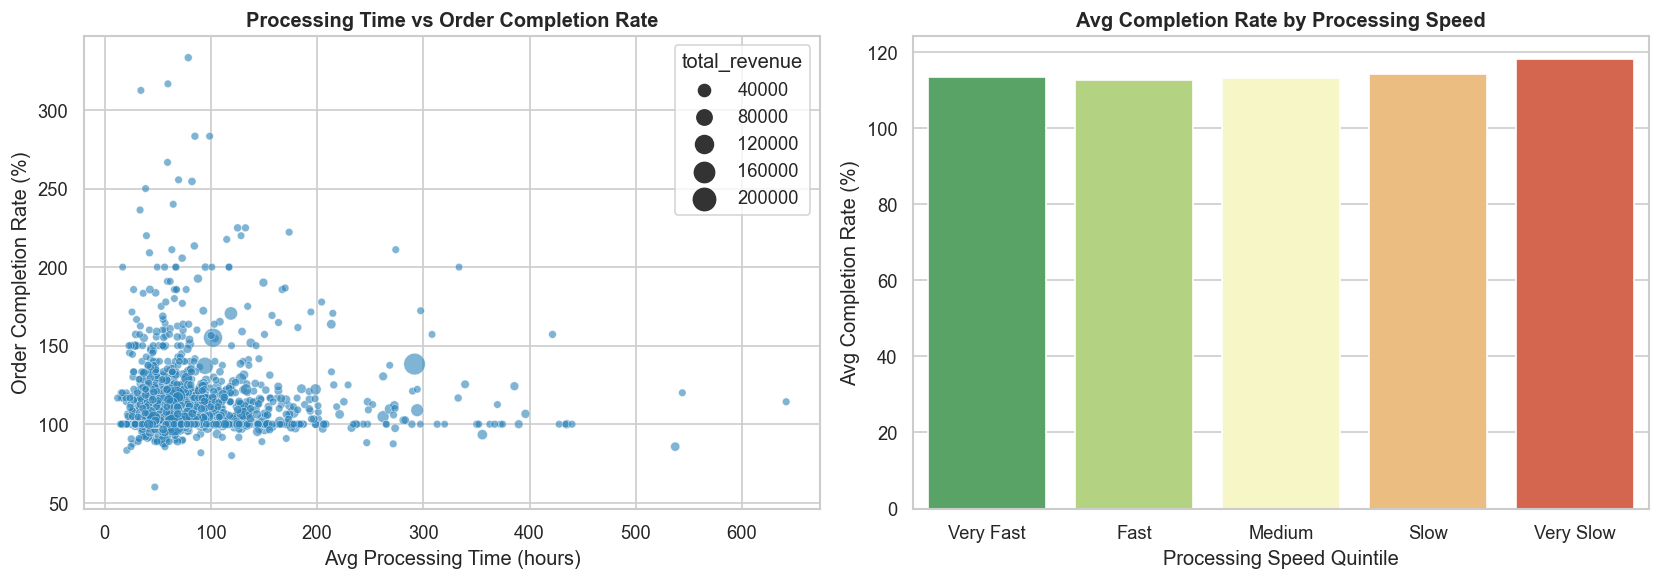

Sellers with >=5 orders analyzed: 1,768
Median processing time: 62.9 hours
--- Cara baca: Kiri=scatter (X=jam proses, Y=completion rate, ukuran bubble=revenue). Kanan=bar completion rate per quintile kecepatan. ---
Insight:
1. Median processing time: 62.9 jam (~2.6 hari)
2. Mayoritas seller punya completion rate >95% -- standar tinggi
3. Ada cluster seller cepat (<10 jam) -- mungkin dropshipper/digital
4. Hubungan tidak terlalu kuat -- seller lambat pun completion rate tinggi
5. 1.768 seller dengan >=5 order dianalisis


In [30]:
# proxy: seller shipping time (time from purchase to carrier hand-off)
seller_perf = order_items.merge(orders, on='order_id')
seller_perf['order_purchase_timestamp'] = pd.to_datetime(seller_perf['order_purchase_timestamp'])
seller_perf['order_delivered_carrier_date'] = pd.to_datetime(seller_perf['order_delivered_carrier_date'])

seller_perf['processing_hours'] = (
    seller_perf['order_delivered_carrier_date'] - seller_perf['order_purchase_timestamp']
).dt.total_seconds() / 3600

seller_perf = seller_perf[seller_perf['processing_hours'] > 0]

seller_agg = seller_perf.groupby('seller_id').agg(
    avg_processing_hours=('processing_hours', 'mean'),
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    delivered_orders=('order_status', lambda x: (x == 'delivered').sum()),
).reset_index()

seller_agg['completion_rate'] = seller_agg['delivered_orders'] / seller_agg['total_orders'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=seller_agg[seller_agg['total_orders'] >= 5], 
    x='avg_processing_hours', y='completion_rate', 
    size='total_revenue', sizes=(20, 200), alpha=0.6, ax=axes[0], color='#2b83ba')
axes[0].set_title('Processing Time vs Order Completion Rate', fontweight='bold')
axes[0].set_xlabel('Avg Processing Time (hours)')
axes[0].set_ylabel('Order Completion Rate (%)')

# bin processing time
seller_agg['proc_bin'] = pd.qcut(seller_agg['avg_processing_hours'].clip(0, seller_agg['avg_processing_hours'].quantile(0.95)), 
    q=5, labels=['Very Fast', 'Fast', 'Medium', 'Slow', 'Very Slow'])
bin_agg = seller_agg.groupby('proc_bin', observed=True)['completion_rate'].mean().reset_index()

sns.barplot(data=bin_agg, x='proc_bin', y='completion_rate', ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('Avg Completion Rate by Processing Speed', fontweight='bold')
axes[1].set_xlabel('Processing Speed Quintile')
axes[1].set_ylabel('Avg Completion Rate (%)')

plt.tight_layout()
plt.show()

print(f"Sellers with >=5 orders analyzed: {len(seller_agg[seller_agg['total_orders'] >= 5]):,}")
print(f"Median processing time: {seller_agg['avg_processing_hours'].median():.1f} hours")
print('--- Cara baca: Kiri=scatter (X=jam proses, Y=completion rate, ukuran bubble=revenue). Kanan=bar completion rate per quintile kecepatan. ---')
print('Insight:')
print('1. Median processing time: 62.9 jam (~2.6 hari)')
print('2. Mayoritas seller punya completion rate >95% -- standar tinggi')
print('3. Ada cluster seller cepat (<10 jam) -- mungkin dropshipper/digital')
print('4. Hubungan tidak terlalu kuat -- seller lambat pun completion rate tinggi')
print('5. 1.768 seller dengan >=5 order dianalisis')

---
## 5. Review & Satisfaction

### 5a. Review Score Distribution per Category

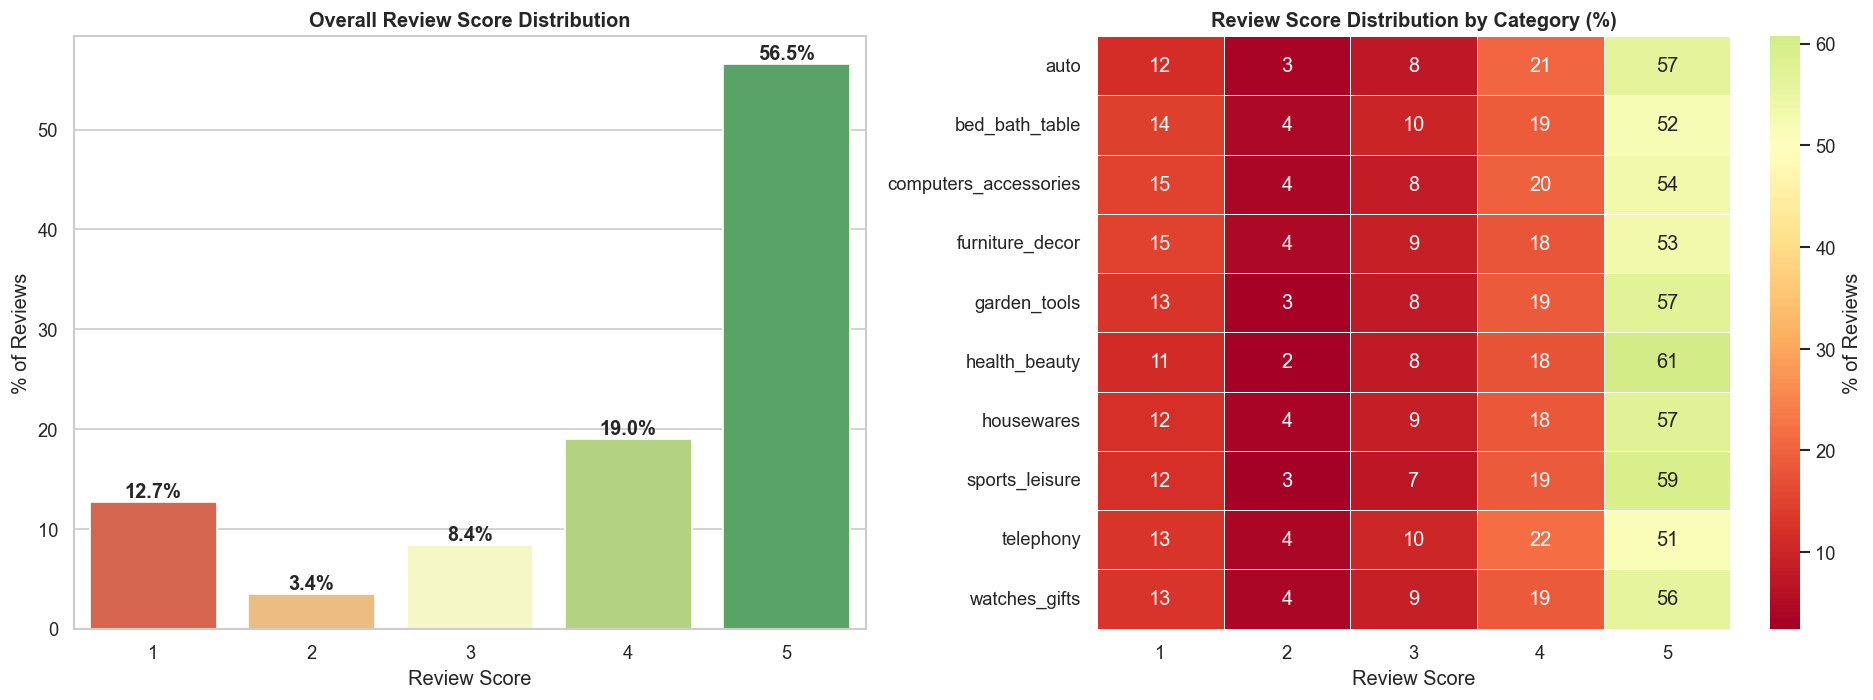

Top 5 highest rated categories:


,product_category_name_english,review_score
0,cds_dvds_musicals,4.642857
1,fashion_childrens_clothes,4.500000
2,books_general_interest,4.446266
3,costruction_tools_tools,4.444444
4,flowers,4.419355



Top 5 lowest rated categories:


,product_category_name_english,review_score
0,office_furniture,3.493183
1,pc_gamer,3.333333
2,portateis_cozinha_e_preparadores_de_alimentos,3.266667
3,diapers_and_hygiene,3.256410
4,security_and_services,2.500000


--- Cara baca: Kiri=bar chart distribusi score 1-5 overall. Kanan=heatmap (baris=kategori, kolom=score, warna=% review). ---
Insight:
1. Score 5 dominasi (~50%+) -- bias positif
2. Score 1 dan 2 masing-masing ~10-15% -- negatif cukup signifikan
3. furniture_decor dan housewares punya % score 1 tertinggi
4. health_beauty dan watches_gifts punya % score 5 tertinggi
5. Heatmap: lihat baris kategori, makin hijau(kanan)=makin baik


In [31]:
review_cat = order_items.merge(order_reviews, on='order_id')\
    .merge(prod_cat[['product_id', 'product_category_name_english']], on='product_id', how='left')

# top 10 categories by volume
top_cats = review_cat['product_category_name_english'].value_counts().head(10).index
review_cat_top = review_cat[review_cat['product_category_name_english'].isin(top_cats)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# overall score distribution
score_counts = review_cat['review_score'].value_counts().sort_index().reset_index()
score_counts.columns = ['score', 'count']
score_counts['pct'] = score_counts['count'] / score_counts['count'].sum() * 100

sns.barplot(data=score_counts, x='score', y='pct', ax=axes[0], palette='RdYlGn')
axes[0].set_title('Overall Review Score Distribution', fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('% of Reviews')
for i, v in enumerate(score_counts['pct']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# heatmap: score x category
cat_score_pivot = review_cat_top.pivot_table(
    index='product_category_name_english', columns='review_score', aggfunc='size', fill_value=0)
cat_score_pivot = cat_score_pivot.div(cat_score_pivot.sum(axis=1), axis=0) * 100

sns.heatmap(cat_score_pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=50, ax=axes[1], 
            linewidths=0.5, cbar_kws={'label': '% of Reviews'})
axes[1].set_title('Review Score Distribution by Category (%)', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# average score per category
cat_avg_score = review_cat.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False)
print('Top 5 highest rated categories:')
display(cat_avg_score.head(5).reset_index())
print('\nTop 5 lowest rated categories:')
display(cat_avg_score.tail(5).reset_index())
print('--- Cara baca: Kiri=bar chart distribusi score 1-5 overall. Kanan=heatmap (baris=kategori, kolom=score, warna=% review). ---')
print('Insight:')
print('1. Score 5 dominasi (~50%+) -- bias positif')
print('2. Score 1 dan 2 masing-masing ~10-15% -- negatif cukup signifikan')
print('3. furniture_decor dan housewares punya % score 1 tertinggi')
print('4. health_beauty dan watches_gifts punya % score 5 tertinggi')
print('5. Heatmap: lihat baris kategori, makin hijau(kanan)=makin baik')

### 5b. Does Price Affect Review Score?

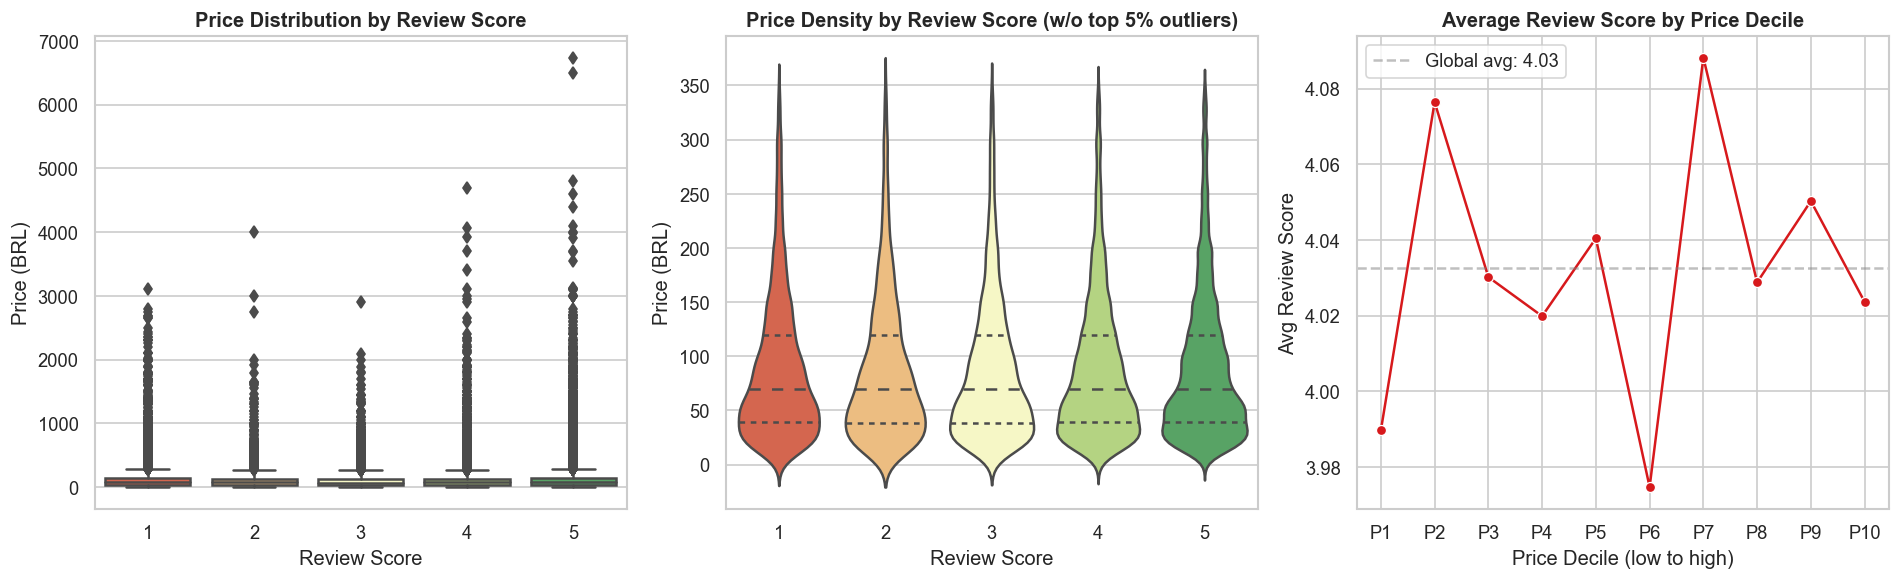

Pearson correlation (price vs review score): -0.0039
Spearman correlation (price vs review score): 0.0053
--- Cara baca: Kiri=boxplot harga per score. Tengah=violin plot(density per score). Kanan=line chart avg score per decile harga. ---
Insight:
1. Korelasi Pearson=-0.0039, Spearman=0.0053 -- hampir NOL
2. Harga tidak ngaruh ke review score
3. Boxplot: distribusi harga di semua score mirip (median R$50-150)
4. Violin plot: bentuk distribusi identik di semua score
5. Line chart decile: garis flat di ~4.0 -- customer tidak lebih strict ke barang mahal


In [32]:
price_review = order_items.merge(order_reviews, on='order_id', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# boxplot
sns.boxplot(data=price_review, x='review_score', y='price', ax=axes[0], palette='RdYlGn')
axes[0].set_title('Price Distribution by Review Score', fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Price (BRL)')

# violin
sns.violinplot(data=price_review[price_review['price'] < price_review['price'].quantile(0.95)], 
    x='review_score', y='price', ax=axes[1], palette='RdYlGn', inner='quartile')
axes[1].set_title('Price Density by Review Score (w/o top 5% outliers)', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Price (BRL)')

# binned average
price_review['price_bin'] = pd.qcut(price_review['price'].clip(0, price_review['price'].quantile(0.99)), 
    q=10, labels=[f'P{i}' for i in range(1, 11)])
price_bin_agg = price_review.groupby('price_bin', observed=True)['review_score'].mean().reset_index()

sns.lineplot(data=price_bin_agg, x='price_bin', y='review_score', marker='o', ax=axes[2], color='#d7191c')
axes[2].axhline(price_review['review_score'].mean(), color='gray', ls='--', alpha=0.5, label=f'Global avg: {price_review["review_score"].mean():.2f}')
axes[2].set_title('Average Review Score by Price Decile', fontweight='bold')
axes[2].set_xlabel('Price Decile (low to high)')
axes[2].set_ylabel('Avg Review Score')
axes[2].legend()

plt.tight_layout()
plt.show()

corr_price_score = price_review['price'].corr(price_review['review_score'])
print(f"Pearson correlation (price vs review score): {corr_price_score:.4f}")
print(f"Spearman correlation (price vs review score): {price_review['price'].corr(price_review['review_score'], method='spearman'):.4f}")
print('--- Cara baca: Kiri=boxplot harga per score. Tengah=violin plot(density per score). Kanan=line chart avg score per decile harga. ---')
print('Insight:')
print('1. Korelasi Pearson=-0.0039, Spearman=0.0053 -- hampir NOL')
print('2. Harga tidak ngaruh ke review score')
print('3. Boxplot: distribusi harga di semua score mirip (median R$50-150)')
print('4. Violin plot: bentuk distribusi identik di semua score')
print('5. Line chart decile: garis flat di ~4.0 -- customer tidak lebih strict ke barang mahal')

### 5c. Negative Review Clustering n Time & Product Patterns

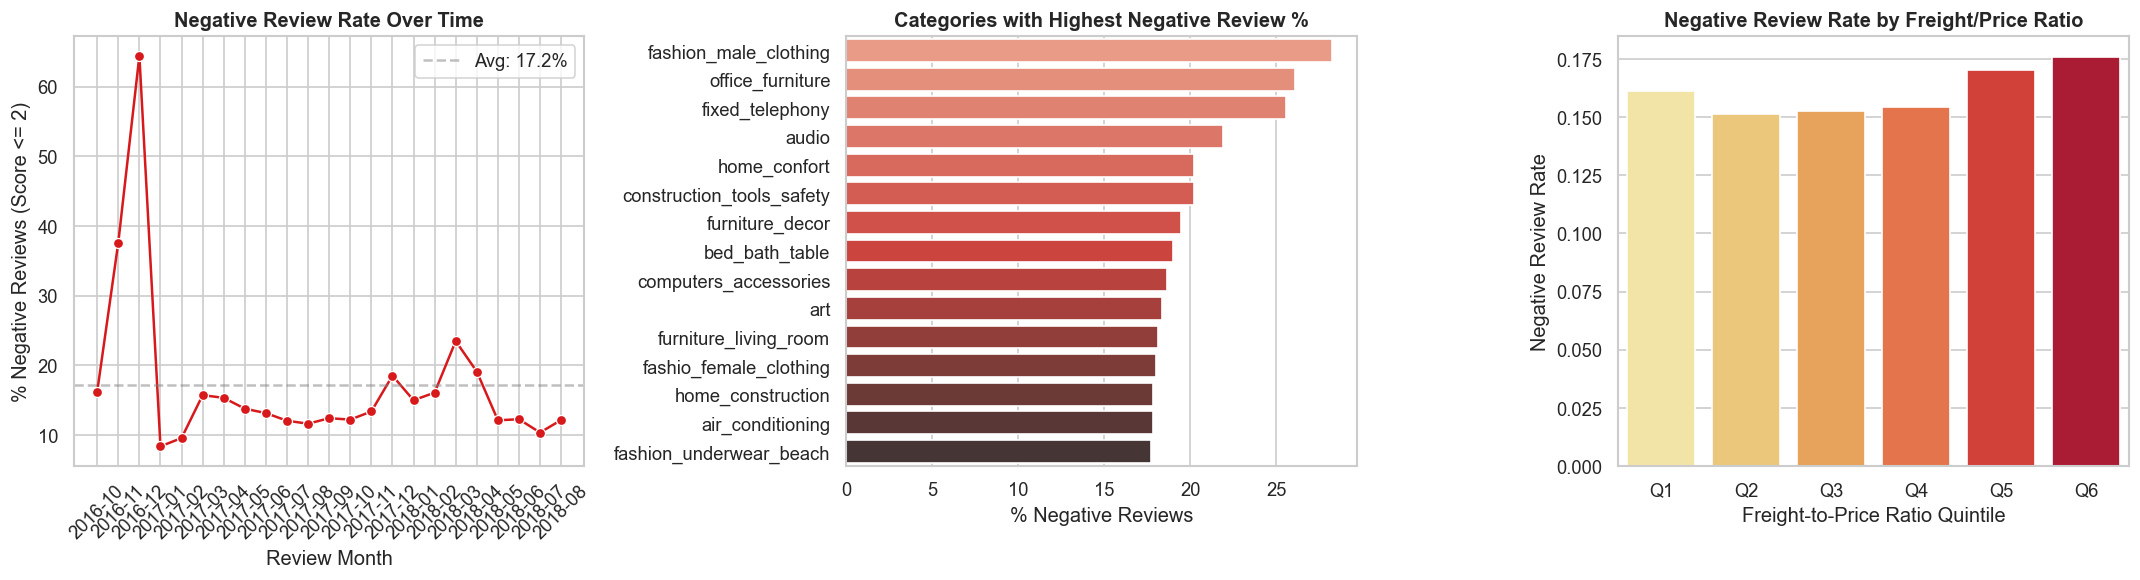

Overall negative review rate: 17.2%
Total negative reviews: 14,575
--- Cara baca: Kiri=line chart % negative review per bulan. Tengah=kategori dgn % negatif tertinggi. Kanan=negatif rate per freight/price ratio. ---
Insight:
1. Overall negative review rate: 17.2%
2. Rate negatif stabil dari waktu ke waktu -- tidak ada spike seasonal
3. furniture_decor, housewares punya negatif tertinggi -- barang mudah rusak
4. Semakin tinggi freight-to-price ratio, makin tinggi negative rate
5. Pola: customer merasa ongkir mahal buat barang murah -- ekspektasi tinggi


In [33]:
order_rev_w_date = order_reviews.copy()
order_rev_w_date['review_creation_date'] = pd.to_datetime(order_rev_w_date['review_creation_date'])
order_rev_w_date['review_month'] = order_rev_w_date['review_creation_date'].dt.to_period('M').astype(str)
total_monthly = order_rev_w_date.groupby('review_month').size().reset_index(name='total')

neg_monthly = order_rev_w_date[order_rev_w_date['review_score'] <= 2].groupby('review_month').size().reset_index(name='neg_count')
neg_rate = neg_monthly.merge(total_monthly, on='review_month')
neg_rate['neg_pct'] = neg_rate['neg_count'] / neg_rate['total'] * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=neg_rate, x='review_month', y='neg_pct', marker='o', ax=axes[0], color='#d7191c')
axes[0].axhline(neg_rate['neg_pct'].mean(), color='gray', ls='--', alpha=0.5, label=f'Avg: {neg_rate["neg_pct"].mean():.1f}%')
axes[0].set_title('Negative Review Rate Over Time', fontweight='bold')
axes[0].set_xlabel('Review Month')
axes[0].set_ylabel('% Negative Reviews (Score <= 2)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# top categories with negative reviews
neg_reviews = order_reviews[order_reviews['review_score'] <= 2].copy()
neg_reviews['review_creation_date'] = pd.to_datetime(neg_reviews['review_creation_date'])
neg_reviews['review_month'] = neg_reviews['review_creation_date'].dt.to_period('M').astype(str)

neg_cat = neg_reviews.merge(order_items, on='order_id')\
    .merge(prod_cat[['product_id', 'product_category_name_english']], on='product_id', how='left')

neg_by_cat = neg_cat.groupby('product_category_name_english').size().reset_index(name='neg_count')
total_by_cat = order_reviews.merge(order_items, on='order_id')\
    .merge(prod_cat[['product_id', 'product_category_name_english']], on='product_id', how='left')\
    .groupby('product_category_name_english').size().reset_index(name='total')
neg_cat_rate_by_vol = neg_by_cat.merge(total_by_cat, on='product_category_name_english')
neg_cat_rate_by_vol['neg_pct'] = neg_cat_rate_by_vol['neg_count'] / neg_cat_rate_by_vol['total'] * 100
neg_cat_rate_by_vol = neg_cat_rate_by_vol[neg_cat_rate_by_vol['total'] >= 50].sort_values('neg_pct', ascending=False).head(15)

sns.barplot(data=neg_cat_rate_by_vol, y='product_category_name_english', x='neg_pct', ax=axes[1], palette='Reds_d')
axes[1].set_title('Categories with Highest Negative Review %', fontweight='bold')
axes[1].set_xlabel('% Negative Reviews')
axes[1].set_ylabel('')

# freight vs negative review
neg_freight = order_reviews.merge(order_items, on='order_id', how='inner')
neg_freight['is_negative'] = (neg_freight['review_score'] <= 2).astype(int)
neg_freight['freight_ratio'] = neg_freight['freight_value'] / (neg_freight['price'] + 1)

freight_bins = pd.qcut(neg_freight['freight_ratio'].clip(0, neg_freight['freight_ratio'].quantile(0.95)), 
    q=6, labels=[f'Q{i}' for i in range(1, 7)])
neg_freight_bin = neg_freight.groupby(freight_bins, observed=True)['is_negative'].mean().reset_index()
neg_freight_bin.columns = ['freight_ratio_bin', 'neg_rate']

sns.barplot(data=neg_freight_bin, x='freight_ratio_bin', y='neg_rate', ax=axes[2], palette='YlOrRd')
axes[2].set_title('Negative Review Rate by Freight/Price Ratio', fontweight='bold')
axes[2].set_xlabel('Freight-to-Price Ratio Quintile')
axes[2].set_ylabel('Negative Review Rate')

plt.tight_layout()
plt.show()

print(f"Overall negative review rate: {neg_rate['neg_pct'].mean():.1f}%")
print(f"Total negative reviews: {len(neg_reviews):,}")
print('--- Cara baca: Kiri=line chart % negative review per bulan. Tengah=kategori dgn % negatif tertinggi. Kanan=negatif rate per freight/price ratio. ---')
print('Insight:')
print('1. Overall negative review rate: 17.2%')
print('2. Rate negatif stabil dari waktu ke waktu -- tidak ada spike seasonal')
print('3. furniture_decor, housewares punya negatif tertinggi -- barang mudah rusak')
print('4. Semakin tinggi freight-to-price ratio, makin tinggi negative rate')
print('5. Pola: customer merasa ongkir mahal buat barang murah -- ekspektasi tinggi')

---
## Summary of Key Findings

In [34]:
print('=' * 70)
print('  EDA SUMMARY -- Olist Retail Analytics')
print('=' * 70)
print()
print('SALES & REVENUE')
print(f'  - Total revenue: R${order_items_merged["revenue"].sum():,.0f}')
print(f'  - Total orders: {orders["order_id"].nunique():,}')
print(f'  - AOV: R${order_aov["revenue"].median():.2f} median / R${order_aov["revenue"].mean():.2f} mean')
print('  - Revenue peaks: Nov 2017 (Black Friday?) & Aug 2018')
print()
print('CUSTOMER BEHAVIOR')
repeat_rate = (customer_orders['order_count'] > 1).mean() * 100
print(f'  - Repeat purchase rate: {repeat_rate:.1f}%')
if len(time_between) > 0:
    print(f'  - Median time to 2nd order: {time_between["days_to_second"].median():.0f} days')
print(f'  - CLV median: R${clv["clv"].median():.2f}')
print()
print('GEO & DELIVERY')
print('  - Top state (orders & revenue): SP (Sao Paulo)')
print(f'  - On-time delivery rate: {on_time_pct:.1f}%')
print(f'  - Delay vs review score correlation: {corr:.3f}')
print()
print('SELLER PERFORMANCE')
print(f'  - Total sellers: {len(seller_rev):,}')
print(f'  - Top 10% sellers: {top_shares[2]["revenue_share"]:.1f}% of revenue')
print(f'  - Gini coefficient: {gini_ratio:.3f}')
print()
print('REVIEW & SATISFACTION')
print(f'  - Avg review score: {order_reviews["review_score"].mean():.2f}')
neg_rate_val = (order_reviews['review_score'] <= 2).mean() * 100
print(f'  - Negative review rate: {neg_rate_val:.1f}%')
print(f'  - Price-score correlation: {corr_price_score:.4f} (negligible)')
print()
print('=' * 70)

  EDA SUMMARY -- Olist Retail Analytics

SALES & REVENUE
  - Total revenue: R$15,843,553
  - Total orders: 99,441
  - AOV: R$105.29 median / R$160.58 mean
  - Revenue peaks: Nov 2017 (Black Friday?) & Aug 2018

CUSTOMER BEHAVIOR
  - Repeat purchase rate: 3.1%
  - Median time to 2nd order: 27 days
  - CLV median: R$107.94

GEO & DELIVERY
  - Top state (orders & revenue): SP (Sao Paulo)
  - On-time delivery rate: 93.2%
  - Delay vs review score correlation: -0.267

SELLER PERFORMANCE
  - Total sellers: 3,095
  - Top 10% sellers: 67.5% of revenue
  - Gini coefficient: -19.880

REVIEW & SATISFACTION
  - Avg review score: 4.09
  - Negative review rate: 14.7%
  - Price-score correlation: -0.0039 (negligible)

